Nome: Alysson Matos

RA: 265057

Curso: Eng. Elétrica (Doutorado)


# Ex03 - Parte 3

##### Imports e definições necessárias

In [187]:
import os

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import requests
import cv2
from PIL import Image

In [188]:
def download_image(url:str) -> str:
    filename = os.path.basename(url)

    if os.path.exists(filename):
        return filename

    response = requests.get(url)

    with open(filename, mode="wb") as file:
        file.write(response.content)

    return filename

In [189]:
url_base = r"https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/main/imgs/{value}.jpg"
values = [75, 80, 95]

filenames = []

for value in values:
    url = url_base.format(value=value)
    filename = download_image(url)
    filenames.append(filename)

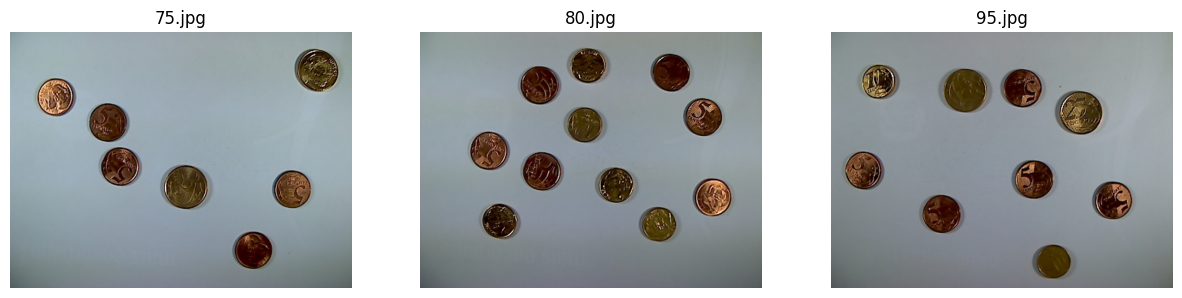

In [190]:
fig, axs = plt.subplots(1,3,figsize=(15, 6))

for i, file in enumerate(filenames):
  plt.subplot(1,3,1+i)
  plt.axis('off')
  plt.title(file)
  img = mpimg.imread(file)
  plt.imshow(img)

##### Exemplo de contagem de moedas em uma imagem

Considere uma das imagens carregadas.

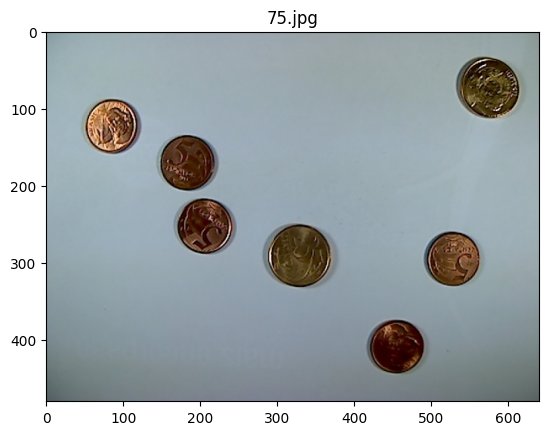

In [191]:
img = mpimg.imread(filenames[0]).astype('uint8')
plt.title(filenames[0])
plt.imshow(img)

Vamos convertê-la para escalas de cinza.

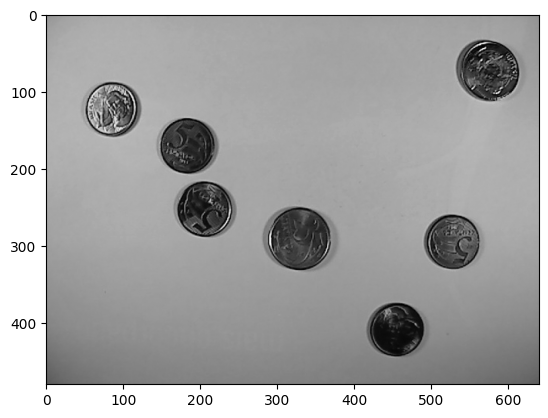

In [192]:
img_gray = np.uint8(0.3*img[:,:,0]+0.59*img[:,:,1]+0.11*img[:,:,2])
plt.imshow(img_gray, cmap='gray')

O código abaixo realiza uma limiarização à imagem em escala de cinza. Como referência conceitual, considere a documentação
[Image Thresholding](https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html). Sobre a função *threshold*: em termos gerais, ela recebe uma imagem em escala de cinza e retorna uma imagem puramente em preto e branco. Ela tem como parâmetros de entrada:
- **src**: imagem em escala de cinza;
- **thresh**: valor do limiar de corte;
- **maxval**: valor a ser atribuído se a condição do limiar for atendida;
- **type**: estilo de binarização. Em especial, o código abaixo usa:
    - THRESH_BINARY: se pixel > thresh, então recebe maxval; senão, recebe 0.
    - THRESH_OTSU: calcula o melhor limiar automaticamente.

Como saída, a função retorna respectivamente o limiar utilizado e a imagem binarizada.

Obs.: abaixo, utiliza-se a transformação de intensidade negativa para tornar preto o fundo e branco os objetos.

Limiar: 149.0


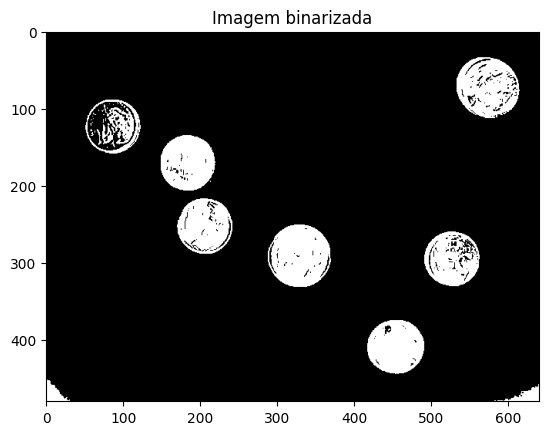

In [193]:
ret, binr = cv2.threshold(255 - img_gray, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
print("Limiar:", ret)
plt.title("Imagem binarizada")
plt.imshow(binr, cmap='gray')

Notamos que há ruídos por dentro e por fora dos contornos dos objetos. A função *morphologyEx* utilizada abaixo, cuja documentação pode ser consultada em [Morphological Transformations](https://docs.opencv.org/4.x/d9/d61/tutorial_py_morphological_ops.html), tem como parâmetros de entrada:
- **src**: imagem binária;
- **op**: tipo de operação morfológica a ser aplicada. Por exemplo, as duas usadas (outras podem ser consultadas na documentação):
    - MORPH_CLOSE, para remover os ruídos internos dos objetos;
    - MORPH_OPEN, para remover os ruídos externos aos objetos.
- **kernel**: elemento estruturante que realiza a operação. À grosso modo, ela varre a imagem de acordo com sua estrutura e dimensão. Quanto menor, menos detalhes afeta; quanto maior, remove objetos maiores. Geralmente, é definido como um quadrado de 1's, mas também pode ser elipse, uma cruz, etc, como exemplificado na documentação.
- **iterations** (opcional): número de vezes que a operação será realizada.

O código abaixo cria uma matriz quadrada como kernel para cada operação. A dimensão pode ser alterada para encontrar aquela que obtém um melhor resultado.

Portanto, primeiro aplica-se a operação de fechamento à imagem binarizada anterior para a remoção de ruídos internos dos objetos e, em seguida, para a remoção de ruídos externos, aplica-se a operação de abertura sobre a imagem resultante do fechamento. O resultado de cada etapa está plotado abaixo.

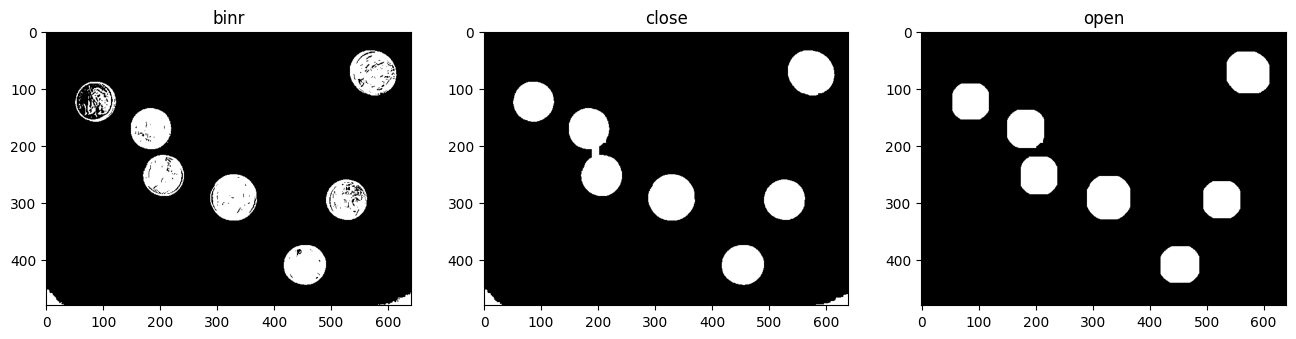

In [194]:
k_cl, k_op = 15, 31
kernel_cl = np.ones((k_cl, k_cl), np.uint8) 
kernel_op = np.ones((k_op, k_op), np.uint8)

close = cv2.morphologyEx(binr, cv2.MORPH_CLOSE, kernel_cl, iterations=1)  
open = cv2.morphologyEx(close, cv2.MORPH_OPEN, kernel_op, iterations=1)

plt.figure(figsize=(16, 6))
plt.subplot(1, 3, 1)
plt.title("binr")
plt.imshow(binr, cmap='gray')
plt.subplot(1, 3, 2)
plt.title("close")
plt.imshow(close, cmap='gray')
plt.subplot(1, 3, 3)
plt.title("open")
plt.imshow(open, cmap='gray')

Uma função importante é a *connectedComponentsWithStats*, com detalhes encontrados em [Structural Analysis and Shape Descriptors](https://docs.opencv.org/3.4/d3/dc0/group__imgproc__shape.html#ga107a78bf7cd25dec05fb4dfc5c9e765f). Ela identifica e rotula cada objeto, além de extrair estatísticas deles. Os parâmetros de entrada são:
- **image**: imagem binária;
- **connectivity** (opcional): define quais vizinhos de um pixel são considerados conectados: 
    - 4, se apenas os vizinhos da direita, esquerda, cima e baixo; 
    - 8, se também quiser considerar os vizinhos diagonais.

Nas saídas, os retornos são:
- **num_labels**: total de objetos encontrados, incluindo o fundo (rótulo 0);
- **labels**: uma matriz do tamanho da imagem original, onde cada entrada recebe o valor do rótulo associado ao respectivo objeto.
- **stats**: uma matriz de dimensão (num_labels, 5), em que:
    - as duas primeiras colunas representam a coordenada (x, y) do pixel mais ao topo e mais à esquerda de cada objeto;
    - as duas colunas seguintes representam largura e altura do objeto, respectivamente;
    - a última coluna guarda o número total de pixels do objeto.
- **centroids**: uma matriz (num_labels, 2) com as coordenadas do centro geométrico de cada objeto. Não necessariamente retorna valores inteiros para as coordenadas.

In [195]:
output = cv2.connectedComponentsWithStats(open, 4)

display(output)

(8,
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(480, 640), dtype=int32),
 array([[     0,      0,    640,    480, 278460],
        [   536,     36,     75,     73,   4805],
        [    55,     92,     64,     63,   3638],
        [   151,    138,     65,     67,   3867],
        [   175,    220,     64,     66,   3786],
        [   291,    254,     76,     76,   5016],
        [   495,    263,     65,     65,   3767],
        [   420,    377,     68,     64,   3861]], dtype=int32),
 array([[316.77099763, 240.64850248],
        [572.94755463,  72.28262227],
        [ 86.49752611, 123.04590434],
        [183.2578226 , 170.89268167],
        [206.29080824, 252.56207079],
        [328.69617225, 291.46909888],
        [526.96283515, 294.97212636],
        [453.55426055, 408.76664077]]))

Exemplo do plot da matriz de labels, com cada objeto destacado com uma cor diferente, associados a cada rótulo que recebeu.

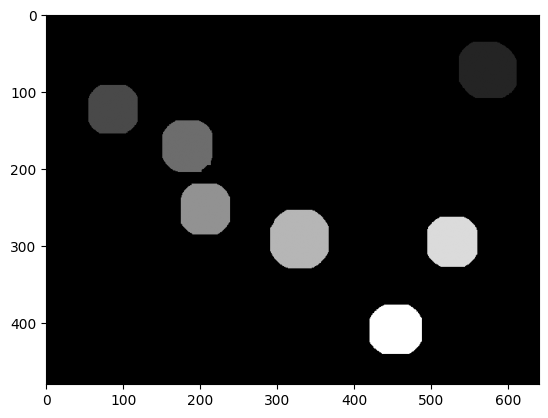

In [196]:
plt.imshow(output[1], cmap='gray')

No código fornecido no notebook da atividade, a função abaixo foi definida para calcular a quantidade de pixels por objeto.

In [197]:
def calc_npixels_label(img, n_labels):
    list_npixels = []
    for v in range(n_labels-1):
        npixels = (img[img == v+1]//(v+1)).sum()
        list_npixels.append(npixels)
    return list_npixels

list_npixels = calc_npixels_label(output[1], output[0])
print(list_npixels)

[np.int64(4805), np.int64(3638), np.int64(3867), np.int64(3786), np.int64(5016), np.int64(3767), np.int64(3861)]


Entretanto, utilizando a própria saída da função *connectedComponentsWithStats*, é possível obter o mesmo resultado, pois a última coluna da matriz *stats* armazena essa informação. Basta desconsiderar a primeira entrada dessa coluna, pois representa a quantidade de pixels do fundo.

In [198]:
list_npixels = output[2][1:, 4]
print(list_npixels)

[4805 3638 3867 3786 5016 3767 3861]


Nesse ponto, o código fornecido na atividade realiza uma classificação:
- se o objeto tem menos de 3500 pixels, é uma moeda de 10 centavos;
- se o objeto tem mais de 4600 pixels, é uma moeda de 25 centavos;
- do contrário, é uma moeda de 5 centavos.

Usando isso, a soma de todas as moedas da imagem é realizada. Por fim, são adicionados, na imagem original, os rótulos das moedas de acordo com a classificação.

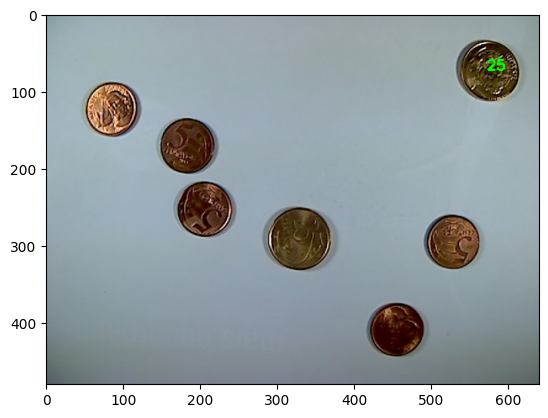

In [199]:
n = 0
p = list_npixels[n]
x = int(output[3][n+1][0])
y = int(output[3][n+1][1])
img_2 = img

if p < 3500:
  img_rot = cv2.putText(img_2, '10', (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
elif p > 4600:
  img_rot = cv2.putText(img_2, '25', (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
else:
  img_rot = cv2.putText(img_2, '5', (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

plt.imshow(img_rot)

##### Algoritmo:

Toda o processo feito anteriormente pode ser condensado em uma função, como abaixo.

In [201]:
def contar_moedas(img):
    img_gray = np.uint8(0.3*img[:,:,0]+0.59*img[:,:,1]+0.11*img[:,:,2])
    ret, binr = cv2.threshold(255 - img_gray, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    
    k_cl, k_op = 15, 31
    kernel_cl = np.ones((k_cl, k_cl), np.uint8) 
    kernel_op = np.ones((k_op, k_op), np.uint8)

    close = cv2.morphologyEx(binr, cv2.MORPH_CLOSE, kernel_cl, iterations=1)  
    open = cv2.morphologyEx(close, cv2.MORPH_OPEN, kernel_op, iterations=1)
    output = cv2.connectedComponentsWithStats(open, 4)
    list_npixels = output[2][1:, 4]

    soma = 0
    for n, p in enumerate(list_npixels - 1):
        x = int(output[3][n+1][0])
        y = int(output[3][n+1][1])

        if p < 3500:
            soma += 10
            cv2.putText(img, '10', (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
        elif p > 4600:
            soma += 25
            cv2.putText(img, '25', (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
        else:
            soma += 5
            cv2.putText(img, '5', (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    
    return soma, img

Imagens originais:

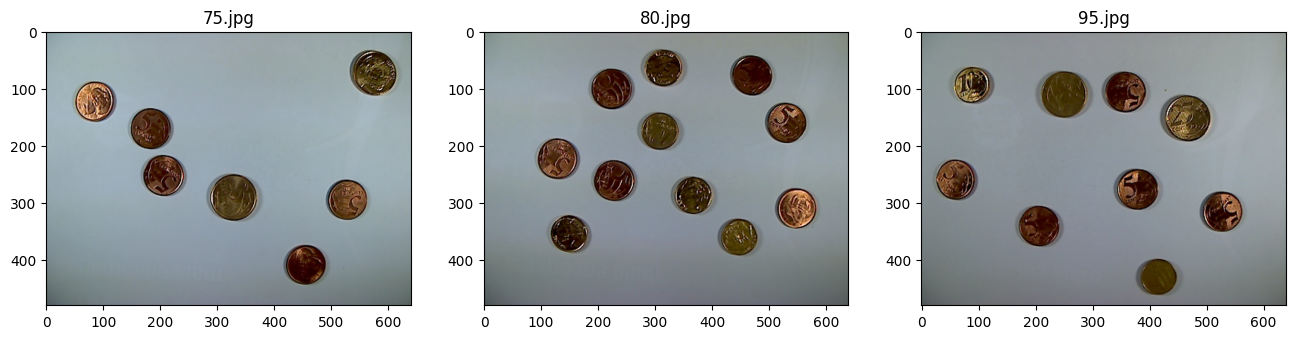

In [214]:
img_1, img_2, img_3 = mpimg.imread(filenames[0]).astype('uint8'), mpimg.imread(filenames[1]).astype('uint8'), mpimg.imread(filenames[2]).astype('uint8')

plt.figure(figsize=(16, 8))
plt.subplot(1, 3, 1)
plt.title(filenames[0])
plt.imshow(img_1)
plt.subplot(1, 3, 2)
plt.title(filenames[1])
plt.imshow(img_2)
plt.subplot(1, 3, 3)
plt.title(filenames[2])
plt.imshow(img_3)

Imagens com objetos rotulados e o valor encontrado:

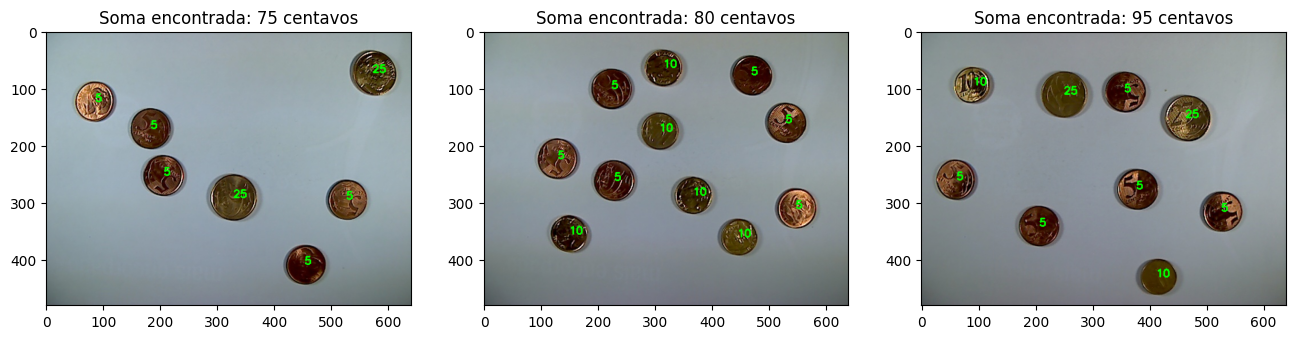

In [217]:
plt.figure(figsize=(16, 8))

plt.subplot(1, 3, 1)
soma, imagem = contar_moedas(img_1)
plt.title(f"Soma encontrada: {soma} centavos")
plt.imshow(imagem)

plt.subplot(1, 3, 2)
soma, imagem = contar_moedas(img_2)
plt.title(f"Soma encontrada: {soma} centavos")
plt.imshow(imagem)

plt.subplot(1, 3, 3)
soma, imagem = contar_moedas(img_3)
plt.title(f"Soma encontrada: {soma} centavos")
plt.imshow(imagem)

##### Comentários Finais

O procedimento visto pode ser resumido no seguinte pipeline:
- limiarização:
    - thresholding;
    - imagem binarizada;
- morfologia:
    - remoção de ruído interno e externo aos objetos;
- componentes:
    - identificar cada objeto individualmente;
- extração de atributos:
    - estatísticas dos objetos;
- classificação:
    - escolher classe com base em número de pixels;
    - realizar a soma;
    - adicionar legenda em cada objeto.

Quanto a possíveis limitações, destaca-se principalmente a etapa de classificação. Nela, cada objeto da imagem é associado a uma classe de acordo com a quantidade de pixels desse objeto. Essa quantidade foi definida a priori e não é uma característica intrínseca. Variações na aquisição da imagem, como zoom diferente, recorte, inclinação, podem gerar valores diferentes de pixels para objetos numa mesma classe. Eventuais alternativas a isso podem ser considerar a razão entre dimensões ou até mesmo optar modelos de aprendizado.